In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/archive/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [ ]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
df.shape

(1470, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df['Attrition'].value_counts()


,count
Attrition,
No,1233
Yes,237


In [ ]:
df['OverTime'].value_counts()

,count
OverTime,
No,1054
Yes,416


In [ ]:
df['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


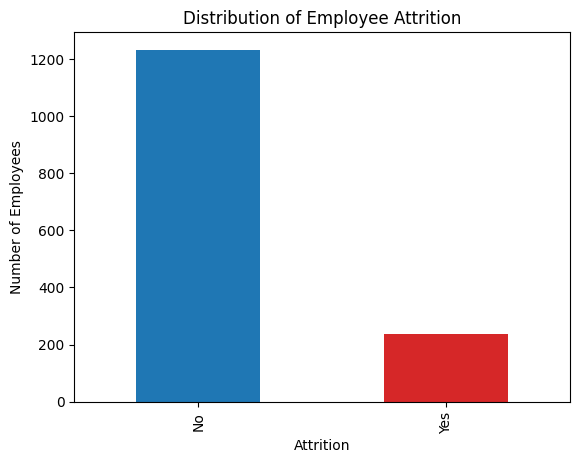

In [ ]:
df['Attrition'].value_counts().plot(kind='bar', color=['tab:blue', 'tab:red'])
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

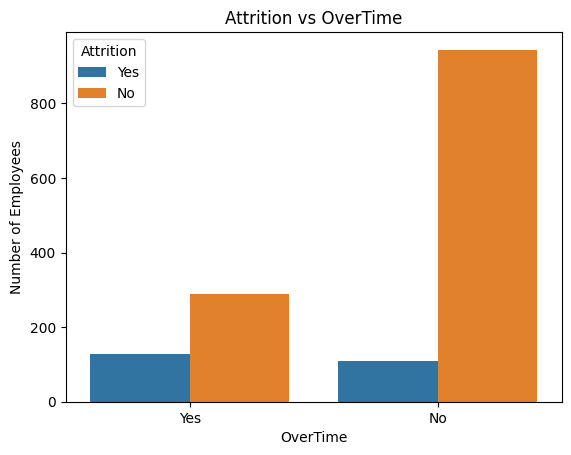

In [ ]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition vs OverTime')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')
plt.show()

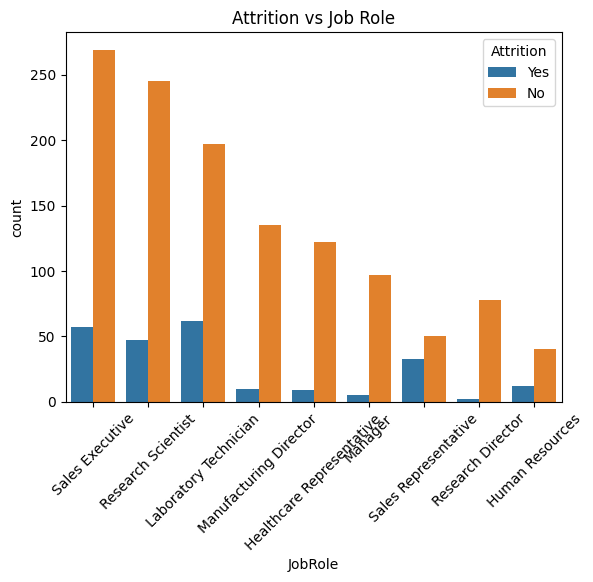

In [ ]:
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.title('Attrition vs Job Role')
plt.xticks(rotation=45)
plt.show()

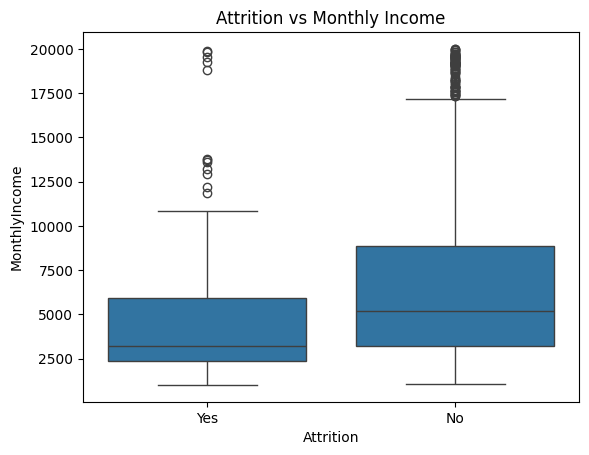

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition vs Monthly Income')
plt.show()

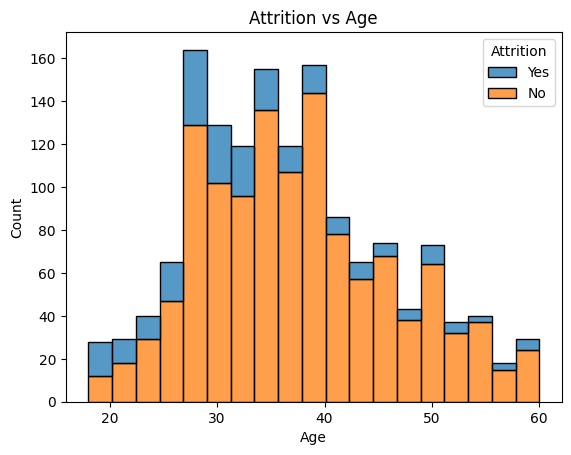

In [ ]:
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack')
plt.title('Attrition vs Age')
plt.show()

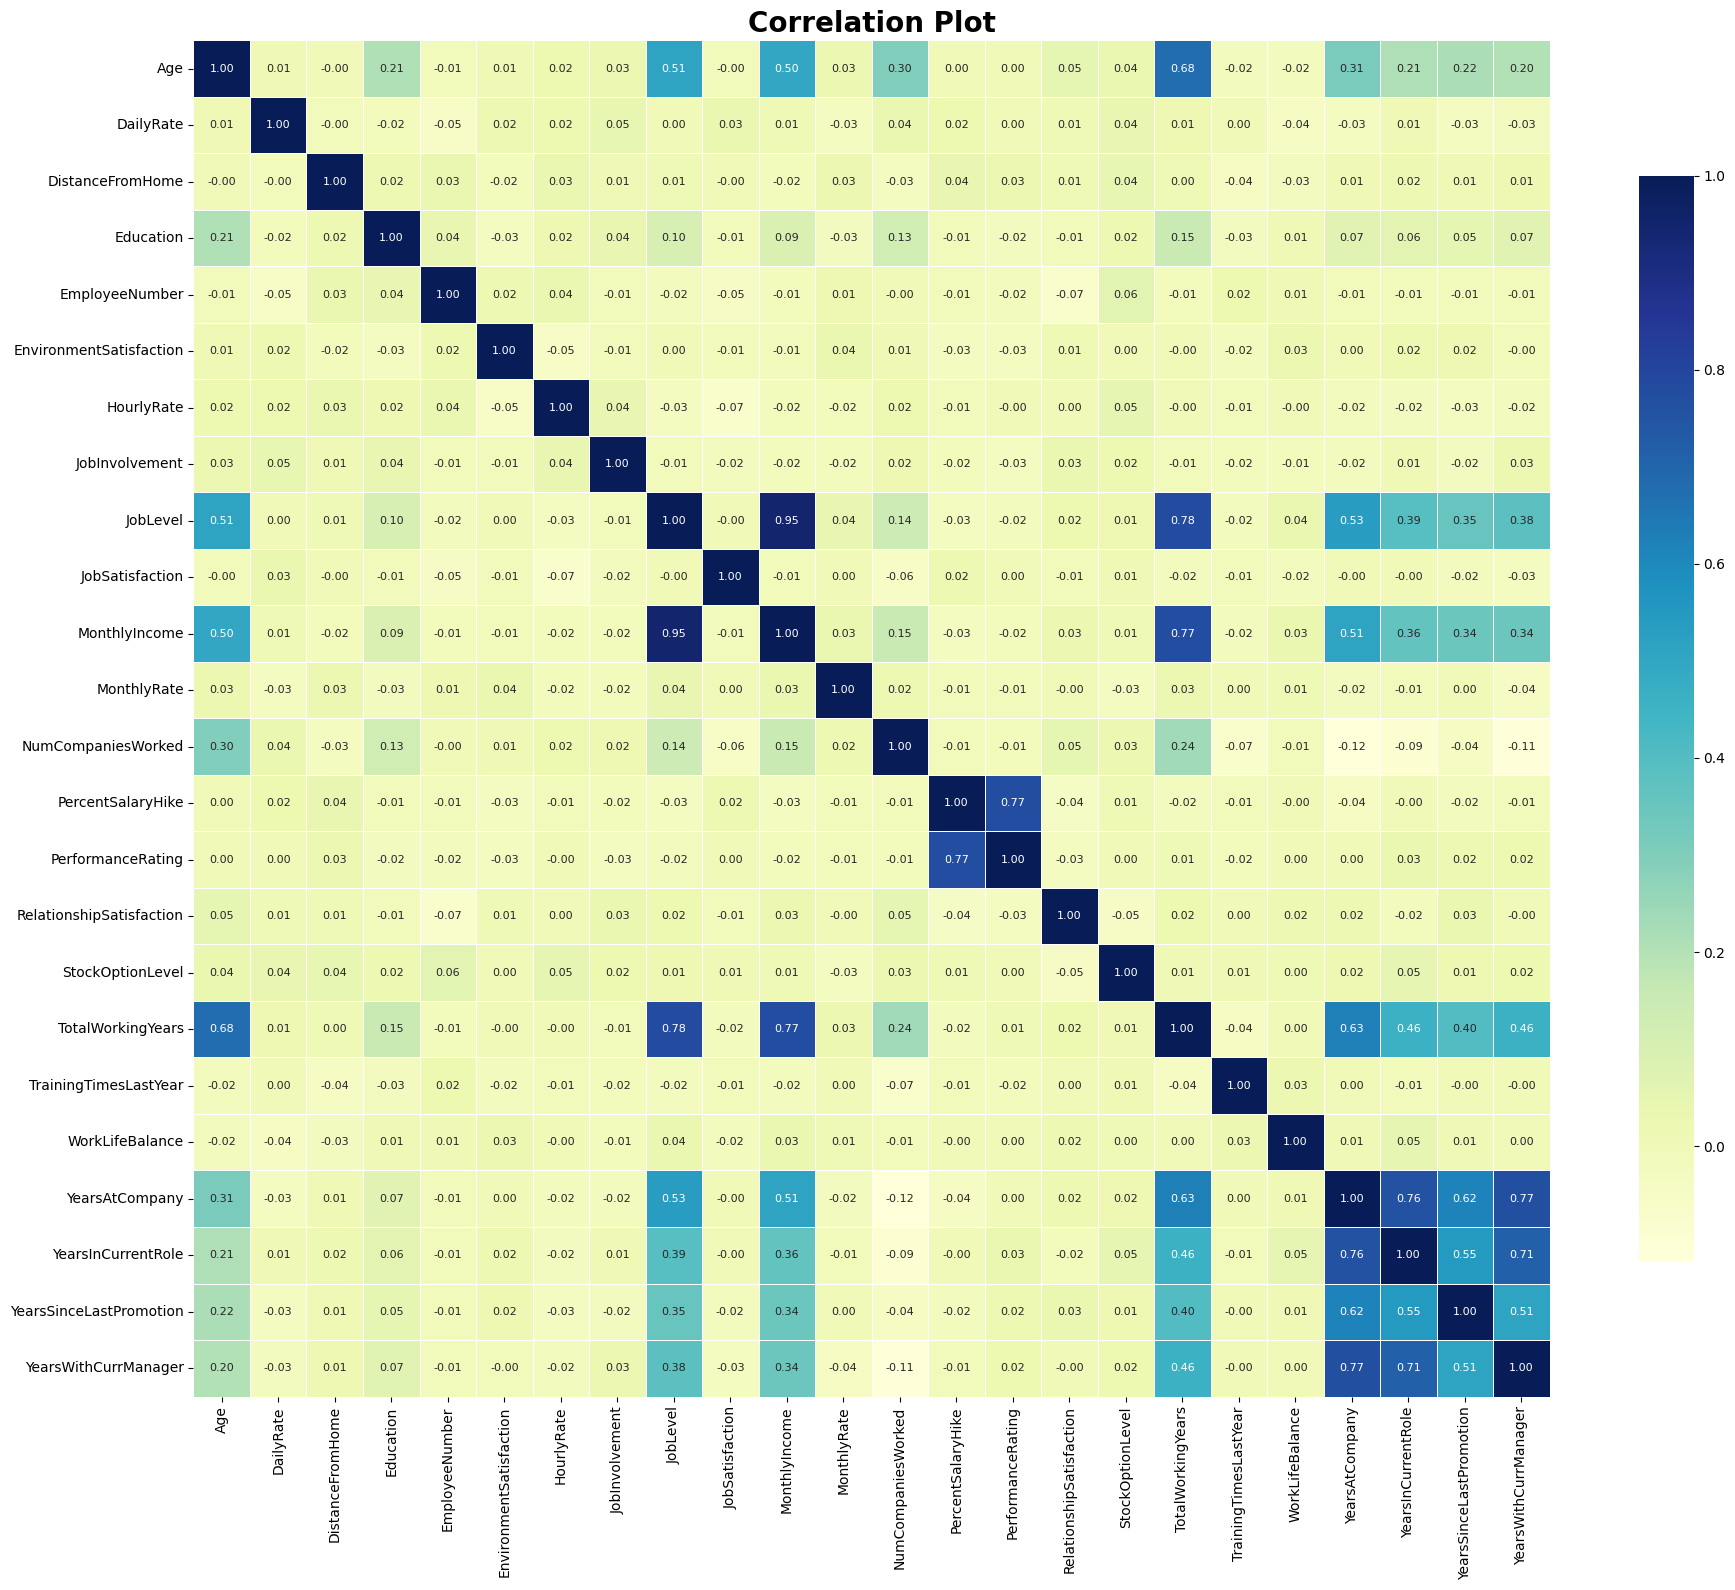

Plotting correlation for 24 numeric variables


In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Remove columns with zero variance (constant values)
# These create gaps in the correlation plot
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

# OR manually drop known constant columns
numeric_df = numeric_df.drop(columns=['EmployeeCount', 'StandardHours'], errors='ignore')

# Create correlation plot without gaps
plt.figure(figsize=(20, 16))
plt.title("Correlation Plot", fontsize=20, fontweight='bold')

sns.heatmap(numeric_df.corr(),
            linewidths=0.5,
            annot=True,
            square=True,
            annot_kws={'size': 8},
            cmap='YlGnBu',
            fmt='.2f',
            cbar_kws={'shrink': 0.8})

plt.tight_layout()
plt.show()

print(f"Plotting correlation for {len(numeric_df.columns)} numeric variables")

The correlation matrix reveals that following are the highly correlated features:

* JobLevel and MonthlyIncome
* JobLevel and TotalWorkingYears
* MonthlyIncome and TotalWorkingYears
* PercentSalaryHike and PerformanceRating
* YearsAtCompany and YearsInCurrentRole
* YearsAtCompany and YearsWithCurrManager


In [ ]:
cols = ["JobLevel", "TotalWorkingYears", "PercentSalaryHike", "YearsInCurrentRole", "YearsWithCurrManager"]
df.drop(columns=cols, inplace=True)


In [ ]:
print(f"After dropping {len(cols)} features: {df.shape}")

After dropping 5 features: (1470, 30)


In [ ]:
# Create binary target y (Attrition 'Yes' -> 1, else 0)
y = (df['Attrition'].str.strip().str.lower() == 'yes').astype(int)

# Define features X (drop the target and any identifiers like EmployeeNumber)
X = df.drop(columns=['Attrition', 'EmployeeNumber'], errors='ignore')

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# One-hot encode categoricals (hint: pd.get_dummies with columns=cat_cols, drop_first=True)
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Reindex columns for deterministic ordering
X_enc = X_enc.reindex(sorted(X_enc.columns), axis=1)

# Train/test split with stratification on y (e.g., 70/30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features for models that need it (LogReg, SVM, MLP)
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Number of features: {X_train.shape[1]}")


Training samples: 1029
Test samples: 441
Number of features: 41


In [ ]:
#Helper function to train and evaluate models
def evaluate_model(name, model, X_train, X_test, y_train, y_test, proba=True):
    """Train a model, compute key metrics, and return a results dict."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if proba and hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = (
            model.decision_function(X_test)
            if hasattr(model, "decision_function")
            else y_pred
        )

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_score)
    except Exception:
        auc = np.nan

    cm = confusion_matrix(y_test, y_pred)

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "confusion_matrix": cm,
        "estimator": model,
    }


Handling Class Imbalance

In [ ]:
# SMOTE for scaled data (Logistic Regression, SVM, MLP)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# SMOTE for unscaled data (Tree-based models)
smote_tree = SMOTE(random_state=42)
X_train_balanced_unscaled, y_train_balanced_unscaled = smote_tree.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print(f"Original class distribution: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_balanced.value_counts().to_dict()}")

Original class distribution: {0: 863, 1: 166}
After SMOTE: {0: 863, 1: 863}


Logistic Regression

In [ ]:

results = []

log_reg = LogisticRegression(max_iter=1000, solver="lbfgs")
results.append(
    evaluate_model(
        "Logistic Regression", log_reg,
        X_train_balanced, X_test_scaled,
        y_train_balanced, y_test
    )
)

coef_df = pd.DataFrame({
    'Feature': X_enc.columns,
    'Coefficient': results[0]['estimator'].coef_[0]
})
print("\nTop 10 Coefficients:")
print(coef_df.sort_values('Coefficient', key=abs, ascending=False).head(10))

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "estimator"]}
    for r in results
])

print("\nModel Performance Summary:")
display(results_df.sort_values("roc_auc", ascending=False))



Top 10 Coefficients:
                              Feature  Coefficient
24            JobRole_Sales Executive     1.139229
19      JobRole_Laboratory Technician     0.885372
39                     YearsAtCompany    -0.852548
32                       OverTime_Yes     0.845817
25       JobRole_Sales Representative     0.814728
1    BusinessTravel_Travel_Frequently     0.745059
4   Department_Research & Development     0.734770
8        EducationField_Life Sciences    -0.709311
40            YearsSinceLastPromotion     0.632658
18            JobRole_Human Resources     0.601174

Model Performance Summary:


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.791383,0.411765,0.690141,0.515789,0.803159


In [ ]:
# After training your logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Check number of features
n_features = log_reg.coef_.shape[1]
print(f"Total features in Logistic Regression: {n_features}")

Total features in Logistic Regression: 41


Tree Based Models

In [ ]:
results = []

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=7)
results.append(
    evaluate_model("Decision Tree", dt,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None,
)
results.append(
    evaluate_model("Random Forest", rf,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
results.append(
    evaluate_model("Gradient Boosting", gb,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

# Support Vector Machine (SVM)
svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
results.append(
    evaluate_model("SVM (RBF)", svm_clf,
                   X_train_balanced, X_test_scaled,
                   y_train_balanced, y_test)
)

# Neural Network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42,
)
results.append(
    evaluate_model("Neural Network (MLP)", mlp,
                   X_train_balanced, X_test_scaled,
                   y_train_balanced, y_test)
)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "estimator"]}
    for r in results
])
results_df.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
4,Neural Network (MLP),0.829932,0.469697,0.436620,0.452555,0.751732
2,Gradient Boosting,0.825397,0.437500,0.295775,0.352941,0.740236
3,SVM (RBF),0.820862,0.437500,0.394366,0.414815,0.736087
1,Random Forest,0.841270,0.513514,0.267606,0.351852,0.722592
0,Decision Tree,0.734694,0.244444,0.309859,0.273292,0.604111


In [ ]:

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt_param_grid = {
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='roc_auc')
dt_grid.fit(X_train_balanced_unscaled, y_train_balanced_unscaled)

print(f"Best max_depth: {dt_grid.best_params_['max_depth']}")

results.append(
    evaluate_model("Decision Tree", dt_grid.best_estimator_,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

Best max_depth: 7


In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "n_estimators": [300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [ ]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

Best max_depth: 7

Top 10 Features by Importance:
                     Feature  Importance              Model
36          StockOptionLevel    0.201250      Decision Tree
36          StockOptionLevel    0.144421  Gradient Boosting
29             MonthlyIncome    0.106076      Decision Tree
29             MonthlyIncome    0.094781  Gradient Boosting
29             MonthlyIncome    0.084651      Random Forest
34  RelationshipSatisfaction    0.080886      Decision Tree
27     MaritalStatus_Married    0.075868  Gradient Boosting
36          StockOptionLevel    0.072983      Random Forest
26           JobSatisfaction    0.072358      Decision Tree
30               MonthlyRate    0.061470      Decision Tree


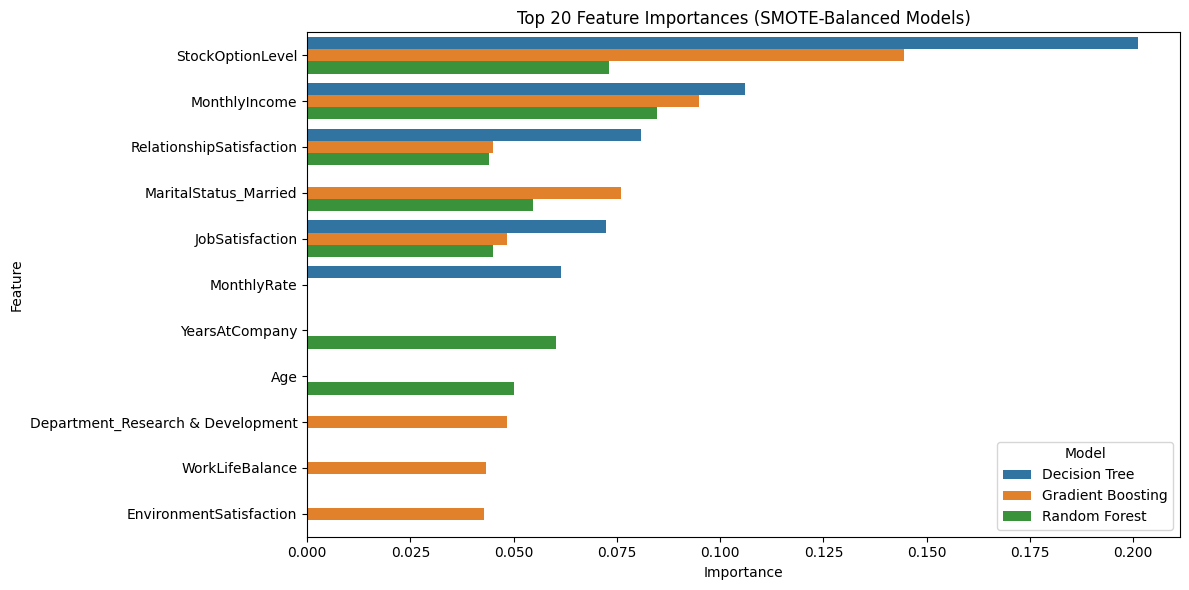

In [ ]:
# Feature Importance
from sklearn.model_selection import GridSearchCV

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt_param_grid = {"max_depth": [3, 5, 7, None]}
dt_grid = GridSearchCV(dt, dt_param_grid, cv=5, scoring='roc_auc')
dt_grid.fit(X_train_balanced_unscaled, y_train_balanced_unscaled)
print(f"Best max_depth: {dt_grid.best_params_['max_depth']}")

results.append(
    evaluate_model("Decision Tree", dt_grid.best_estimator_,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
results.append(
    evaluate_model("Random Forest", rf,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
results.append(
    evaluate_model("Gradient Boosting", gb,
                   X_train_balanced_unscaled, X_test,
                   y_train_balanced_unscaled, y_test)
)

# Feature Importance Analysis
feature_importances = []
feature_names = X_enc.columns.tolist()

for i, name in enumerate(["Decision Tree", "Random Forest", "Gradient Boosting"]):
    estimator = results[-(3-i)]['estimator']
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': estimator.feature_importances_,
        'Model': name
    })
    feature_importances.append(importance_df)

all_importances = pd.concat(feature_importances)
print("\nTop 10 Features by Importance:")
print(all_importances.sort_values('Importance', ascending=False).head(10))

# Visualize
plt.figure(figsize=(12, 6))
top_features = all_importances.sort_values('Importance', ascending=False).head(20)
sns.barplot(x='Importance', y='Feature', hue='Model', data=top_features)
plt.title('Top 20 Feature Importances (SMOTE-Balanced Models)')
plt.tight_layout()
plt.show()

In [ ]:
#Support Vector Machine (SVM)
svm_clf = SVC(random_state=42, probability=True)
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf"],
    "gamma": ["scale", "auto"]
}

In [ ]:
mlp = MLPClassifier(random_state=42, max_iter=500)

mlp_param_grid = {
    "hidden_layer_sizes": [(64, 32)],   #hidden layer sizes 64 and 32
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001]
}

In [ ]:
# Store models and their parameter grids in a dictionary
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

models_and_params = {
    "Logistic Regression": (log_reg, log_reg_param_grid),
    "Decision Tree": (dt, dt_param_grid),
    "Random Forest": (rf, rf_param_grid),
    "Gradient Boosting": (gb, gb_param_grid),
    "SVM": (svm_clf, svm_param_grid),
    "Neural Network (MLP)": (mlp, mlp_param_grid),
}

print("Models and hyperparameter grids defined successfully.")

Models and hyperparameter grids defined successfully.


In [ ]:
tuned_results = []
best_estimators = {}

for name, (model, param_grid) in models_and_params.items():
    print(f"Tuning {name}...")

    # Determine which data to use based on the model type
    if name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]:
        X_train_tuned = X_train_balanced
        y_train_tuned = y_train_balanced
    else:
        X_train_tuned = X_train_balanced_unscaled
        y_train_tuned = y_train_balanced_unscaled

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=5,
        verbose=0,
        n_jobs=-1,
    )

    grid_search.fit(X_train_tuned, y_train_tuned)

    best_estimator = grid_search.best_estimator_
    best_score = grid_search.best_score_
    best_params = grid_search.best_params_

    best_estimators[name] = best_estimator

    tuned_results.append({
        "model": name,
        "best_score": best_score,
        "best_params": best_params,
        "estimator": best_estimator,
    })

print("Hyperparameter tuning completed for all models.")

Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning SVM...
Tuning Neural Network (MLP)...
Hyperparameter tuning completed for all models.


In [ ]:
tuned_model_evaluation_results = []

for name, estimator in best_estimators.items():
    print(f"Evaluating tuned {name}...")

    # Determine which data to use for evaluation based on the model type
    if name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]:
        X_train_input_for_evaluate = X_train_balanced
        X_test_input_for_evaluate = X_test_scaled
        y_train_input = y_train_balanced
    else:
        X_train_input_for_evaluate = X_train_balanced_unscaled
        X_test_input_for_evaluate = X_test
        y_train_input = y_train_balanced_unscaled

    proba_support = hasattr(estimator, "predict_proba")

    evaluation_result = evaluate_model(
        name,
        estimator,
        X_train_input_for_evaluate,
        X_test_input_for_evaluate,
        y_train_input,
        y_test,
        proba=proba_support
    )
    tuned_model_evaluation_results.append(evaluation_result)

tuned_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["confusion_matrix", "estimator"]}
    for r in tuned_model_evaluation_results
])
display(tuned_results_df.sort_values("roc_auc", ascending=False))

print("Evaluation of tuned models completed.")

Evaluating tuned Logistic Regression...
Evaluating tuned Decision Tree...
Evaluating tuned Random Forest...
Evaluating tuned Gradient Boosting...
Evaluating tuned SVM...
Evaluating tuned Neural Network (MLP)...


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.786848,0.401709,0.661972,0.500000,0.802589
5,Neural Network (MLP),0.823129,0.450704,0.450704,0.450704,0.763114
2,Random Forest,0.841270,0.513514,0.267606,0.351852,0.722592
3,Gradient Boosting,0.843537,0.535714,0.211268,0.303030,0.718691
4,SVM,0.827664,0.446809,0.295775,0.355932,0.707842
1,Decision Tree,0.734694,0.244444,0.309859,0.273292,0.604111


Evaluation of tuned models completed.


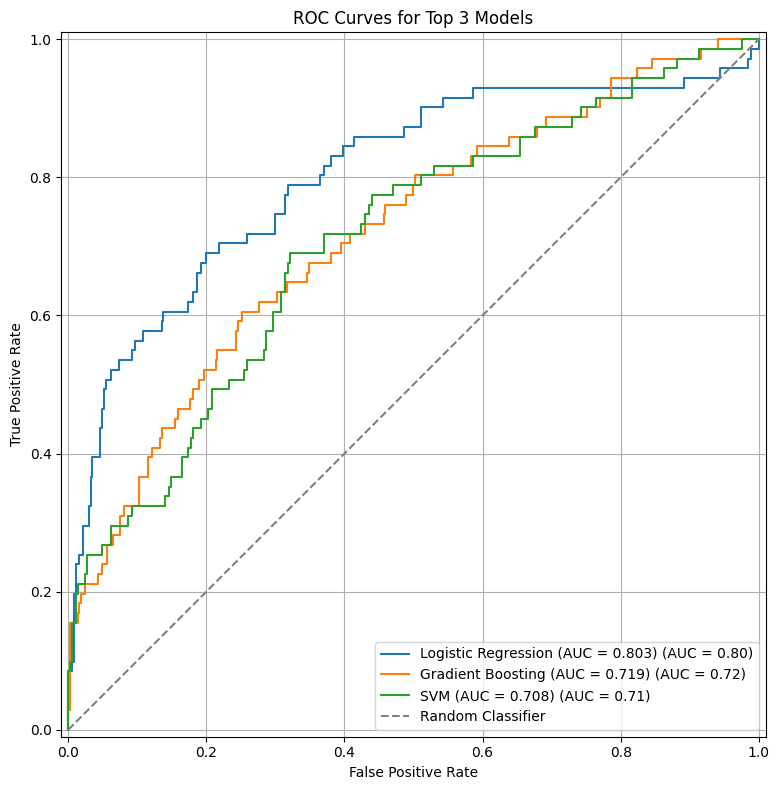

ROC curves for top 3 models plotted successfully.


In [ ]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Only plot top 3 models by ROC AUC
top_3_models = ["Logistic Regression", "SVM", "Gradient Boosting"]

for r in tuned_model_evaluation_results:
    model_name = r["model"]

    # Skip if not in top 3
    if model_name not in top_3_models:
        continue

    estimator = r["estimator"]

    # Determine which data to use for evaluation based on the model type
    if model_name in ["Logistic Regression", "SVM", "Neural Network (MLP)"]:
        X_test_input = X_test_scaled
    else:
        X_test_input = X_test

    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_test_input)[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(X_test_input)
    else:
        # Some models might not have proba or decision_function, skip them or handle as needed
        print(f"Skipping {model_name} for ROC curve: No predict_proba or decision_function.")
        continue

    RocCurveDisplay.from_predictions(
        y_test, y_score, name=f"{model_name} (AUC = {r['roc_auc']:.3f})", ax=ax
    )

plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")
plt.title("ROC Curves for Top 3 Models")  # Updated title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROC curves for top 3 models plotted successfully.")

In [ ]:
for r in tuned_model_evaluation_results:
    print("\nModel:", r["model"])
    print(r["confusion_matrix"])


Model: Logistic Regression
[[300  70]
 [ 24  47]]

Model: Decision Tree
[[302  68]
 [ 49  22]]

Model: Random Forest
[[352  18]
 [ 52  19]]

Model: Gradient Boosting
[[357  13]
 [ 56  15]]

Model: SVM
[[344  26]
 [ 50  21]]

Model: Neural Network (MLP)
[[331  39]
 [ 39  32]]
